In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

# constants
AU = 1.496e11
c = 3e8


In [2]:
POPULATION = {
    "Station crew": 700,
    "Mining supervision": 350,
    "Industrial processing": 400,
    "Logistics": 250,
    "Science & medical": 150,
    "Visitors": 250
}

# Robot fleet
ROBOTS = {
    "Excavation": 1200,
    "Transport": 500,
    "Survey": 150,
    "Maintenance": 150
}

# Mining parameters
MINING = {
    "annual_output_tons": 20_000_000,
    "robot_productivity_tpd": 38
}

# Cargo ships
SHIPS = {
    "capacity_tons": 1500,
    "ships_per_day": 22
}

# Dock infrastructure
DOCKS = {
    "cargo_docks": 4,
    "cycle_hours": 3
}

# Communication bandwidth allocation
BANDWIDTH = {
    "Robotics control": 0.3,
    "Telemetry": 0.25,
    "Science data": 0.25,
    "Crew communication": 0.2
}

# Communication latency environment
COMMUNICATION = {
    "earth_min_km": 300e6,
    "earth_max_km": 600e6
}

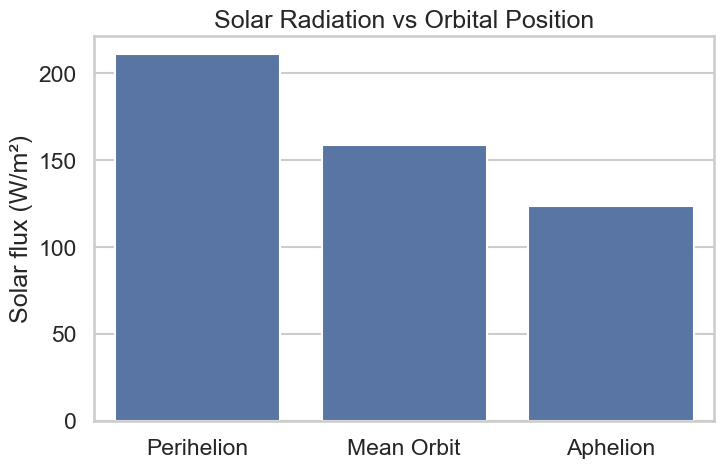

In [3]:
# orbit distances
orbit = pd.DataFrame({
    "distance_AU":[2.54,2.93,3.32],
    "position":["Perihelion","Mean Orbit","Aphelion"]
})

# solar flux
S0 = 1361
orbit["solar_flux_W_m2"] = S0/(orbit["distance_AU"]**2)

plt.figure(figsize=(8,5))
sns.barplot(data=orbit,x="position",y="solar_flux_W_m2")
plt.title("Solar Radiation vs Orbital Position")
plt.ylabel("Solar flux (W/m²)")
plt.xlabel("")
plt.show()

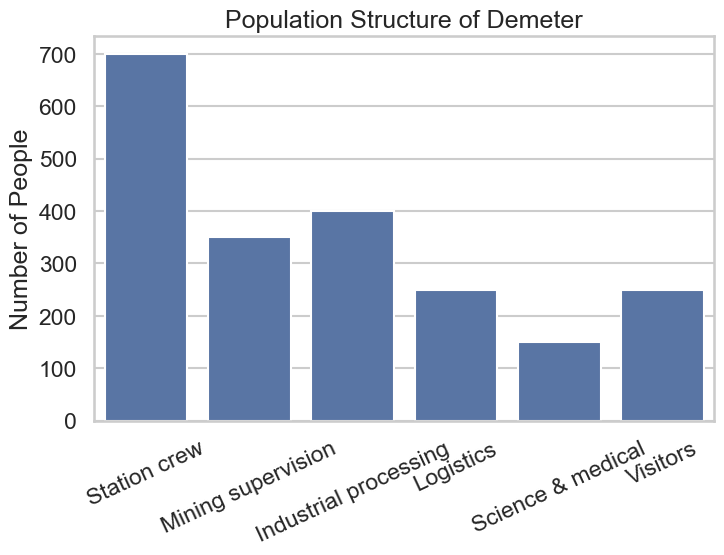

In [4]:
pop_df = pd.DataFrame({
    "Group": list(POPULATION.keys()),
    "People": list(POPULATION.values())
})

plt.figure(figsize=(8,5))
sns.barplot(data=pop_df, x="Group", y="People")

plt.title("Population Structure of Demeter")
plt.ylabel("Number of People")
plt.xlabel("")
plt.xticks(rotation=25)

plt.show()

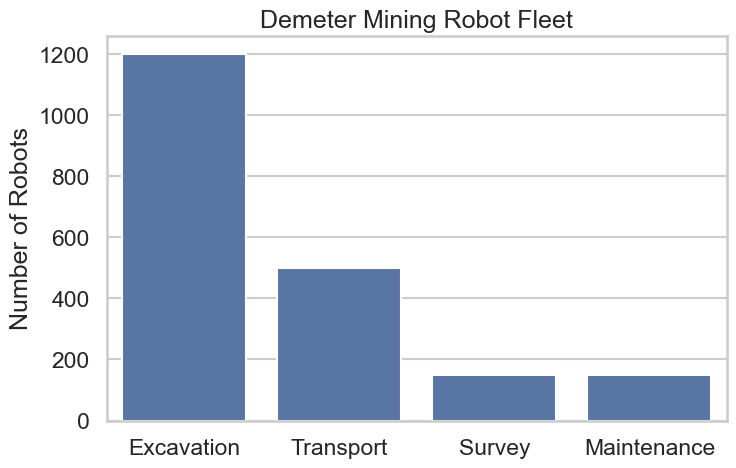

In [5]:
robot_df = pd.DataFrame({
    "Robot Type": list(ROBOTS.keys()),
    "Count": list(ROBOTS.values())
})

plt.figure(figsize=(8,5))
sns.barplot(data=robot_df, x="Robot Type", y="Count")

plt.title("Demeter Mining Robot Fleet")
plt.ylabel("Number of Robots")
plt.xlabel("")

plt.show()

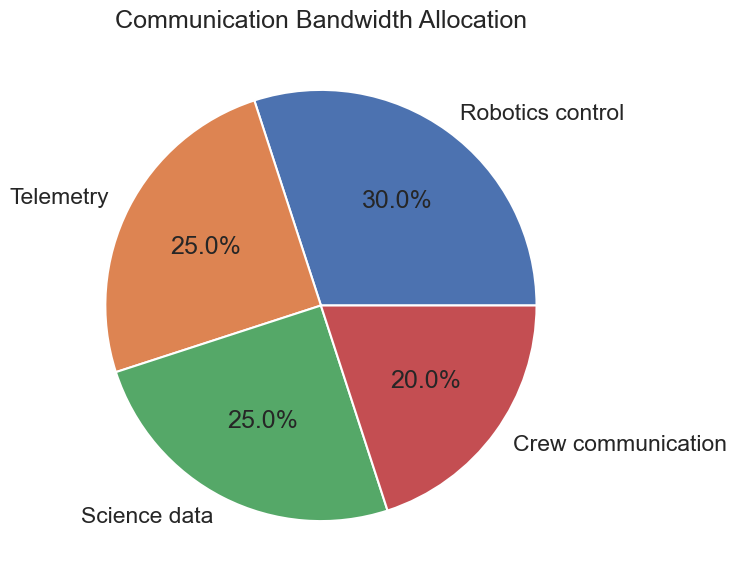

In [6]:
bandwidth_df = pd.DataFrame({
    "System": list(BANDWIDTH.keys()),
    "Gbps": list(BANDWIDTH.values())
})

plt.figure(figsize=(7,7))

plt.pie(
    bandwidth_df["Gbps"],
    labels=bandwidth_df["System"],
    autopct="%1.1f%%"
)

plt.title("Communication Bandwidth Allocation")

plt.show()

| group                      | headcount | role (ru)                 |
| --------------------------- | ----------- | -------------------- |
| Permanent station crew      | 700         | инженеры, управление |
| Mining supervision teams    | 350         | контроль добычи      |
| Industrial processing staff | 400         | переработка ресурсов |
| Logistics & transport       | 250         | доки, груз           |
| Science & medical           | 150         | исследования         |
| Visitors / rotation crews   | 250         | сменные экипажи      |


Demeter hosts approximately **2.000–2.200** inhabitants, including permanent crew, rotating mining teams, industrial staff, logistics operators, and scientific personnel. (https://www.supercluster.com/editorial/reaching-for-the-high-frontier)
This population size supports continuous mining operations while maintaining manageable life-support requirements.

Psyche is a metallic asteroid with a diameter of ~226 km. The total mass is enormous, but extraction is limited by logistics.
| system            | scope    |
| ------------------ | ---------- |
| Population Demeter | ~2100      |
| Mining robots      | ~2000      |
| Extraction rate    | 20 Mt/year |
| Daily cargo flow   | ~55 kt/day |

payload per cycle = 400 kg

cycles per hour = 4

production per robot = 1.6 t/hour
([robots](https://arxiv.org/abs/1612.03238))

| type                | number |
| ------------------ | ---------- |
| Excavation robots  | 1200       |
| Transport robots   | 500        |
| Maintenance robots | 200        |
| Survey drones      | 100        |


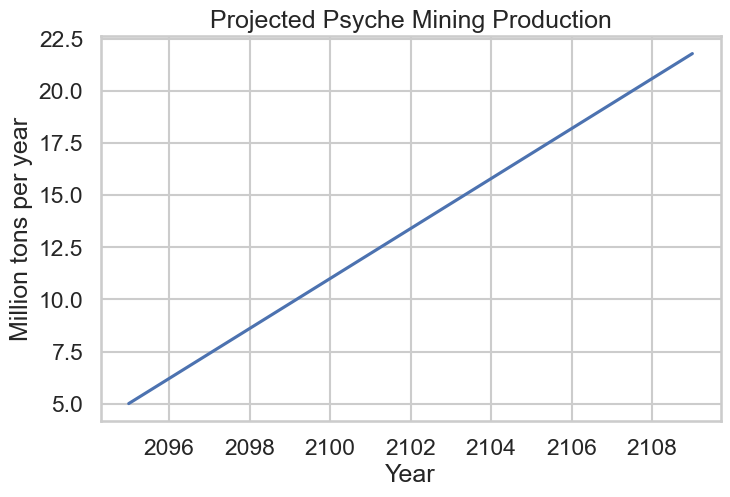

In [14]:
years = np.arange(2095,2110)

production = 5 + (years-2095)*1.2

df_prod = pd.DataFrame({
    "Year":years,
    "Production_Mt":production
})

plt.figure(figsize=(8,5))
sns.lineplot(data=df_prod,x="Year",y="Production_Mt")
plt.title("Projected Psyche Mining Production")
plt.ylabel("Million tons per year")
plt.show()

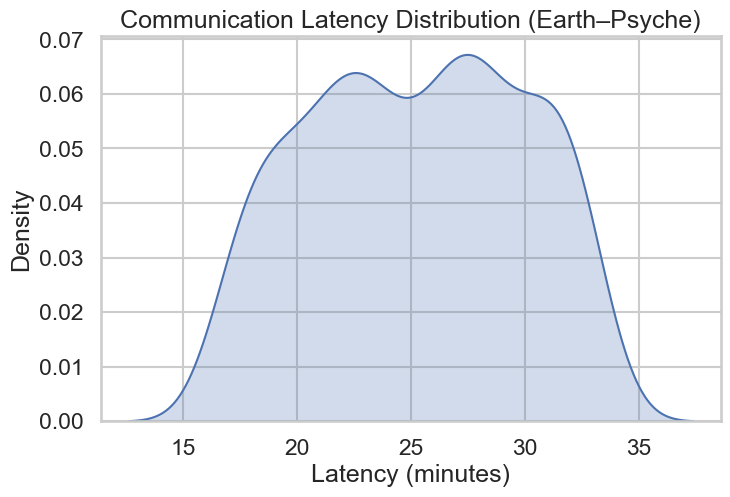

In [7]:
distances = np.random.uniform(
    COMMUNICATION["earth_min_km"],
    COMMUNICATION["earth_max_km"],
    500
)

c = 3e5  # km/s

latency = distances / c / 60

lat_df = pd.DataFrame({
    "Latency (minutes)": latency
})

plt.figure(figsize=(8,5))
sns.kdeplot(lat_df["Latency (minutes)"], fill=True)

plt.title("Communication Latency Distribution (Earth–Psyche)")
plt.xlabel("Latency (minutes)")

plt.show()

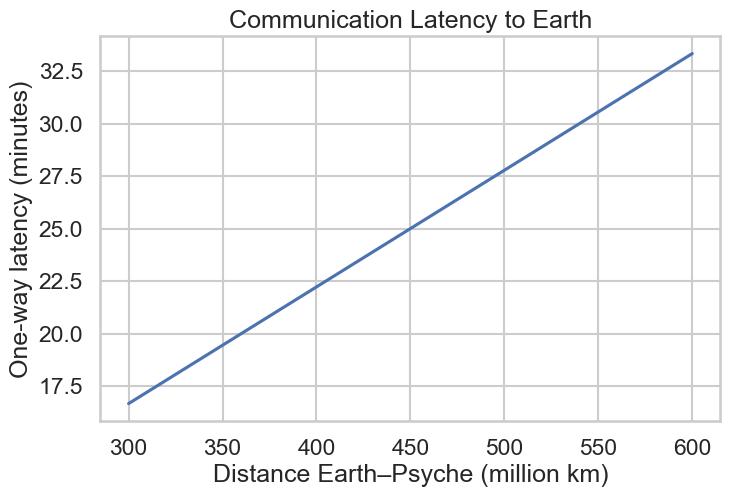

In [17]:
c = 3e8
dist_km = np.linspace(300e6,600e6,100)

latency_min = dist_km*1000/c/60

plt.figure(figsize=(8,5))
sns.lineplot(x=dist_km/1e6,y=latency_min)
plt.xlabel("Distance Earth–Psyche (million km)")
plt.ylabel("One-way latency (minutes)")
plt.title("Communication Latency to Earth")
plt.show()

| indicator               | value   |
| ------------------------ | ---------- |
| Export                  | 12 Mt/year |
| Ship capacity              | 1500 t     |
| Ships per year           | **≈ 8000** |
| Ships per day          | **≈ 22**   |


Demeter exports approximately 12 million tons of processed material per year, requiring about 8,000 cargo spacecraft annually, or roughly 20–25 dockings per day.

| phase              | time  |
| ----------------- | ------ |
| docking           | 30 min |
| unloading/loading | 2 h    |
| departure prep    | 30 min |


full time = 3 h
=> 8 ships/day
=> 3-4 cargo docking ports


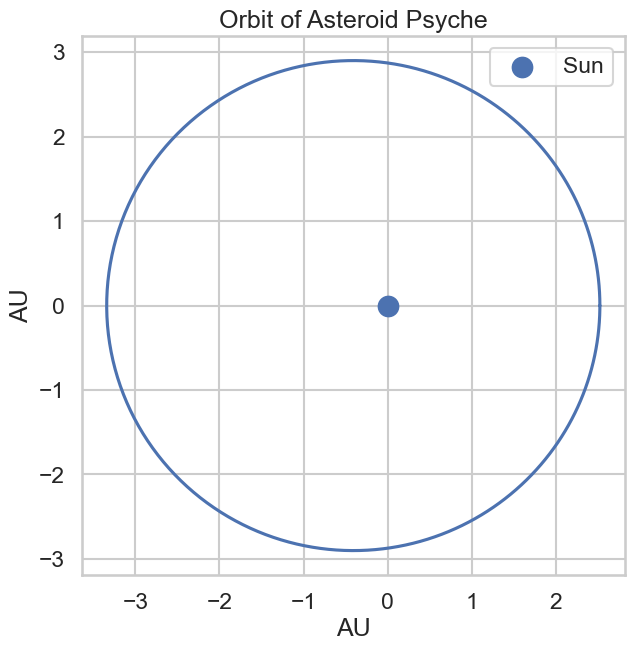

In [19]:
AU = 1.496e11
mu_sun = 1.327e20

# Psyche orbit parameters
a = 2.93 * AU
e = 0.14

theta = np.linspace(0,2*np.pi,400)

r = a*(1-e**2)/(1+e*np.cos(theta))

x = r*np.cos(theta)/AU
y = r*np.sin(theta)/AU

plt.figure(figsize=(7,7))
plt.plot(x,y)
plt.scatter(0,0,s=200,label="Sun")
plt.title("Orbit of Asteroid Psyche")
plt.xlabel("AU")
plt.ylabel("AU")
plt.axis("equal")
plt.legend()
plt.show()

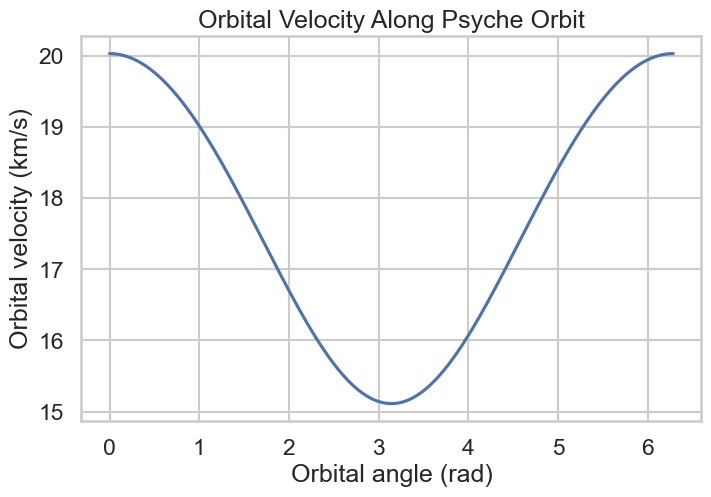

In [21]:
v = np.sqrt(mu_sun*(2/r - 1/a))/1000

plt.figure(figsize=(8,5))
sns.lineplot(x=theta,y=v)
plt.xlabel("Orbital angle (rad)")
plt.ylabel("Orbital velocity (km/s)")
plt.title("Orbital Velocity Along Psyche Orbit")
plt.show()

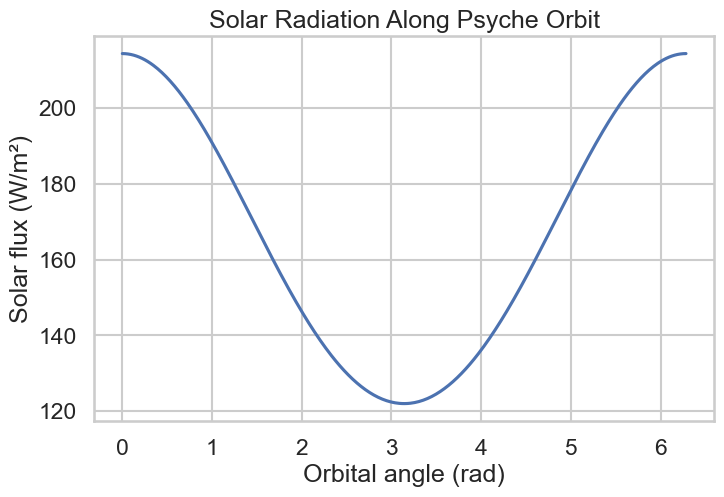

In [22]:
S0 = 1361
solar_flux = S0*(AU/r)**2

plt.figure(figsize=(8,5))
sns.lineplot(x=theta,y=solar_flux)
plt.xlabel("Orbital angle (rad)")
plt.ylabel("Solar flux (W/m²)")
plt.title("Solar Radiation Along Psyche Orbit")
plt.show()

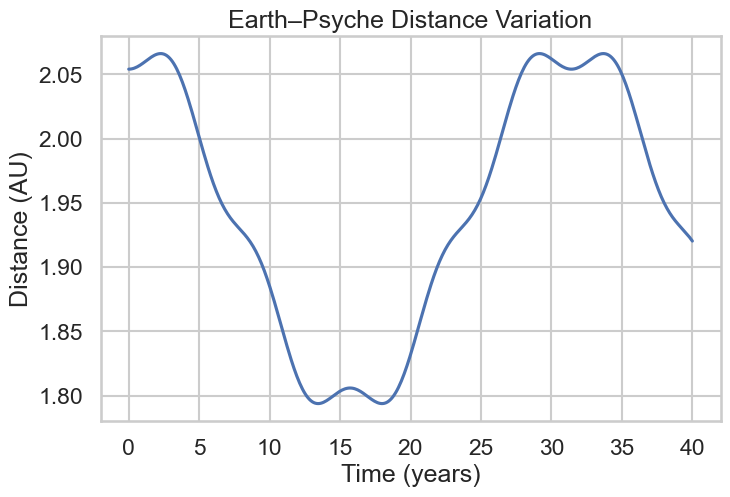

In [25]:
t = np.linspace(0,40,400)

earth = 1 + 0.016*np.cos(t)
psyche = 2.93 + 0.14*np.cos(t/5)

dist = np.abs(psyche-earth)

plt.figure(figsize=(8,5))
sns.lineplot(x=t,y=dist)
plt.xlabel("Time (years)")
plt.ylabel("Distance (AU)")
plt.title("Earth–Psyche Distance Variation")
plt.show()

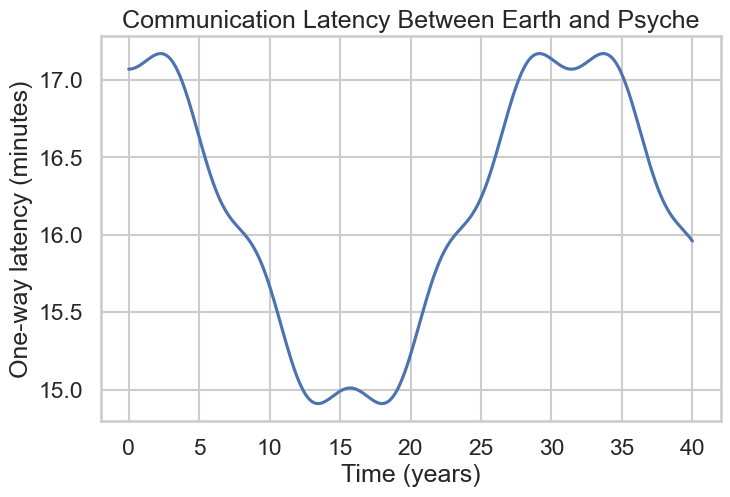

In [26]:
c = 3e8

dist_m = dist*AU
latency = dist_m/c/60

plt.figure(figsize=(8,5))
sns.lineplot(x=t,y=latency)
plt.xlabel("Time (years)")
plt.ylabel("One-way latency (minutes)")
plt.title("Communication Latency Between Earth and Psyche")
plt.show()

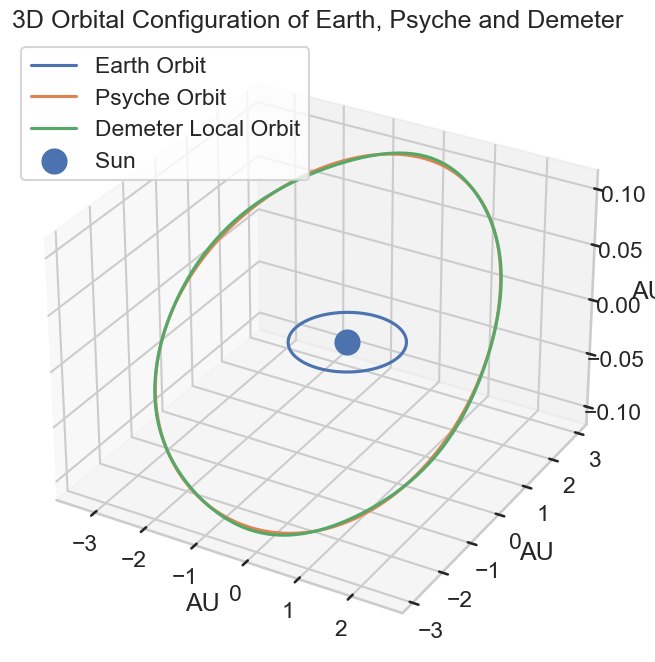

In [27]:
from mpl_toolkits.mplot3d import Axes3D

AU = 1.496e11

# orbital parameters
a_earth = 1 * AU
a_psyche = 2.93 * AU
e_psyche = 0.14

theta = np.linspace(0,2*np.pi,600)

# Earth orbit
r_earth = a_earth
x_e = r_earth*np.cos(theta)/AU
y_e = r_earth*np.sin(theta)/AU
z_e = np.zeros_like(theta)

# Psyche orbit
r_psy = a_psyche*(1-e_psyche**2)/(1+e_psyche*np.cos(theta))
x_p = r_psy*np.cos(theta)/AU
y_p = r_psy*np.sin(theta)/AU
z_p = 0.1*np.sin(theta)

# Demeter orbit around Psyche
r_dem = 0.01
x_d = x_p + r_dem*np.cos(theta)
y_d = y_p + r_dem*np.sin(theta)
z_d = z_p + 0.002*np.sin(theta*5)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_e,y_e,z_e,label="Earth Orbit")
ax.plot(x_p,y_p,z_p,label="Psyche Orbit")
ax.plot(x_d,y_d,z_d,label="Demeter Local Orbit")

ax.scatter(0,0,0,s=300,label="Sun")

ax.set_xlabel("AU")
ax.set_ylabel("AU")
ax.set_zlabel("AU")
ax.set_title("3D Orbital Configuration of Earth, Psyche and Demeter")

ax.legend()

plt.show()

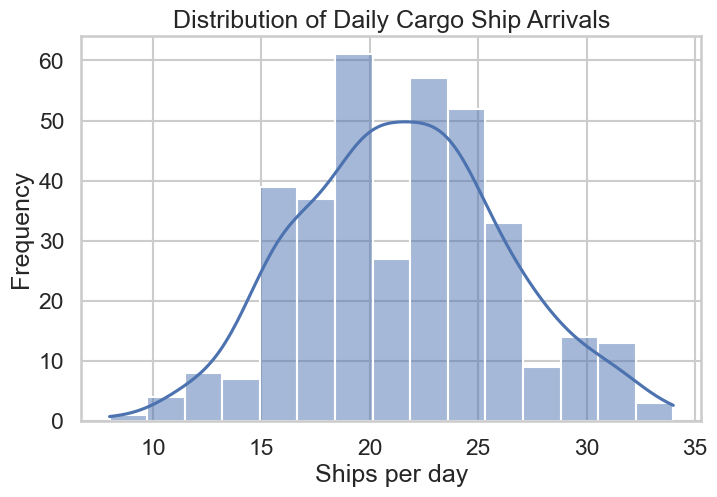

In [36]:
ships_per_day = 22
days = 365

np.random.seed(42)

arrivals = np.random.poisson(ships_per_day, days)

df = pd.DataFrame({"Ships per day": arrivals})

plt.figure(figsize=(8,5))
sns.histplot(df["Ships per day"], bins=15, kde=True)

plt.title("Distribution of Daily Cargo Ship Arrivals")
plt.xlabel("Ships per day")
plt.ylabel("Frequency")

plt.show()


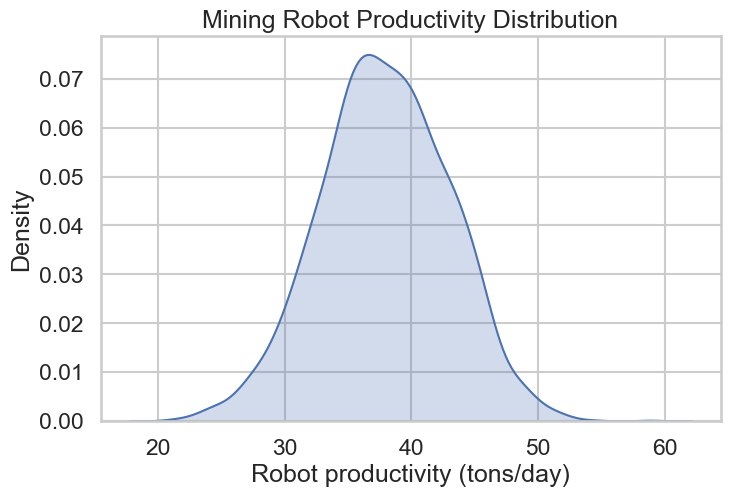

In [8]:
robot_count = sum(ROBOTS.values())

productivity = np.random.normal(
    MINING["robot_productivity_tpd"],
    5,
    robot_count
)

prod_df = pd.DataFrame({
    "Robot productivity (tons/day)": productivity
})

plt.figure(figsize=(8,5))
sns.kdeplot(prod_df["Robot productivity (tons/day)"], fill=True)

plt.title("Mining Robot Productivity Distribution")

plt.show()